In [234]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder as ohe
from sklearn.preprocessing import StandardScaler as scaler
from sklearn.impute import SimpleImputer # Import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline as pipeline
from sklearn.compose import ColumnTransformer as columnTransformer
from sklearn.metrics import r2_score, mean_absolute_error as mae

In [235]:
raw_data="https://gist.githubusercontent.com/anu-006/2db8313ad268e9e6de0fe6eed77d7af7/raw/89974b18d63ce8faf1be5db7cc767acf53957388/electric_dataset.csv"

In [236]:
data=pd.read_csv(raw_data)

In [237]:
data

,Brand,Model,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,FastCharge_KmH,RapidCharge,PowerTrain,PlugType,BodyStyle,Segment,Seats,PriceEuro
0,Tesla,Model 3 Long Range Dual Motor,4.6,233,450,161,940,Yes,AWD,Type 2 CCS,Sedan,D,5,55480
1,Volkswagen,ID.3 Pure,10.0,160,270,167,250,Yes,RWD,Type 2 CCS,Hatchback,C,5,30000
2,Polestar,2,4.7,210,400,181,620,Yes,AWD,Type 2 CCS,Liftback,D,5,56440
3,BMW,iX3,6.8,180,360,206,560,Yes,RWD,Type 2 CCS,SUV,D,5,68040
4,Honda,e,9.5,145,170,168,190,Yes,RWD,Type 2 CCS,Hatchback,B,4,32997
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Nissan,Ariya 63kWh,7.5,160,330,191,440,Yes,FWD,Type 2 CCS,Hatchback,C,5,45000
99,Audi,e-tron S Sportback 55 quattro,4.5,210,335,258,540,Yes,AWD,Type 2 CCS,SUV,E,5,96050
100,Nissan,Ariya e-4ORCE 63kWh,5.9,200,325,194,440,Yes,AWD,Type 2 CCS,Hatchback,C,5,50000
101,Nissan,Ariya e-4ORCE 87kWh Performance,5.1,200,375,232,450,Yes,AWD,Type 2 CCS,Hatchback,C,5,65000


In [238]:
data.shape

(103, 14)

In [239]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            103 non-null    object 
 1   Model            103 non-null    object 
 2   AccelSec         103 non-null    float64
 3   TopSpeed_KmH     103 non-null    int64  
 4   Range_Km         103 non-null    int64  
 5   Efficiency_WhKm  103 non-null    int64  
 6   FastCharge_KmH   103 non-null    object 
 7   RapidCharge      103 non-null    object 
 8   PowerTrain       103 non-null    object 
 9   PlugType         103 non-null    object 
 10  BodyStyle        103 non-null    object 
 11  Segment          103 non-null    object 
 12  Seats            103 non-null    int64  
 13  PriceEuro        103 non-null    int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 11.4+ KB


In [240]:
(data.isnull().sum()/len(data))*100

,0
Brand,0.0
Model,0.0
AccelSec,0.0
TopSpeed_KmH,0.0
Range_Km,0.0
Efficiency_WhKm,0.0
FastCharge_KmH,0.0
RapidCharge,0.0
PowerTrain,0.0
PlugType,0.0


In [241]:
data.duplicated().sum()

np.int64(0)

In [242]:
data.describe()

,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,Seats,PriceEuro
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,7.396117,179.194175,338.786408,189.165049,4.883495,55811.563107
std,3.017430,43.573030,126.014444,29.566839,0.795834,34134.665280
min,2.100000,123.000000,95.000000,104.000000,2.000000,20129.000000
25%,5.100000,150.000000,250.000000,168.000000,5.000000,34429.500000
50%,7.300000,160.000000,340.000000,180.000000,5.000000,45000.000000
75%,9.000000,200.000000,400.000000,203.000000,5.000000,65000.000000
max,22.400000,410.000000,970.000000,273.000000,7.000000,215000.000000


In [243]:
corr=data.corr(numeric_only=True)
corr

,AccelSec,TopSpeed_KmH,Range_Km,Efficiency_WhKm,Seats,PriceEuro
AccelSec,1.000000,-0.786195,-0.677062,-0.382904,-0.175335,-0.627174
TopSpeed_KmH,-0.786195,1.000000,0.746662,0.355675,0.126470,0.829057
Range_Km,-0.677062,0.746662,1.000000,0.313077,0.300163,0.674844
Efficiency_WhKm,-0.382904,0.355675,0.313077,1.000000,0.301230,0.396705
Seats,-0.175335,0.126470,0.300163,0.301230,1.000000,0.020920
PriceEuro,-0.627174,0.829057,0.674844,0.396705,0.020920,1.000000


<Axes: >

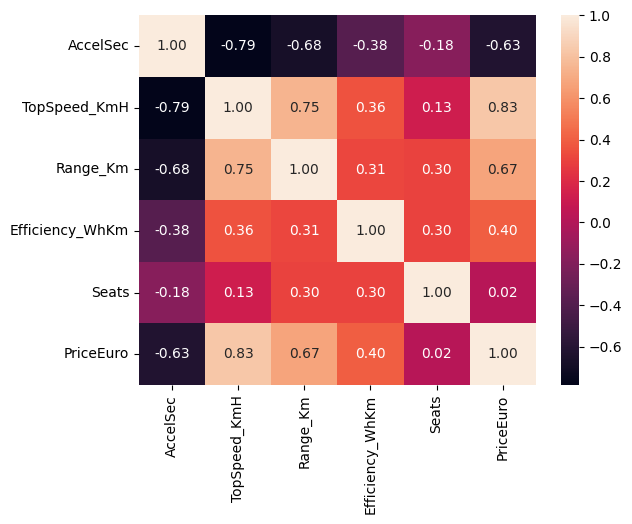

In [244]:
sns.heatmap(corr,annot=True,fmt='.2f')

In [245]:
num=['AccelSec', 'TopSpeed_KmH', 'Range_Km',
       'Efficiency_WhKm', 'FastCharge_KmH','Seats','PriceEuro']

cat=['Brand', 'Model','RapidCharge', 'PowerTrain','PlugType', 'BodyStyle']

data['FastCharge_KmH'] = pd.to_numeric(data['FastCharge_KmH'], errors='coerce')

In [246]:
data.columns

Index(['Brand', 'Model', 'AccelSec', 'TopSpeed_KmH', 'Range_Km',
       'Efficiency_WhKm', 'FastCharge_KmH', 'RapidCharge', 'PowerTrain',
       'PlugType', 'BodyStyle', 'Segment', 'Seats', 'PriceEuro'],
      dtype='object')

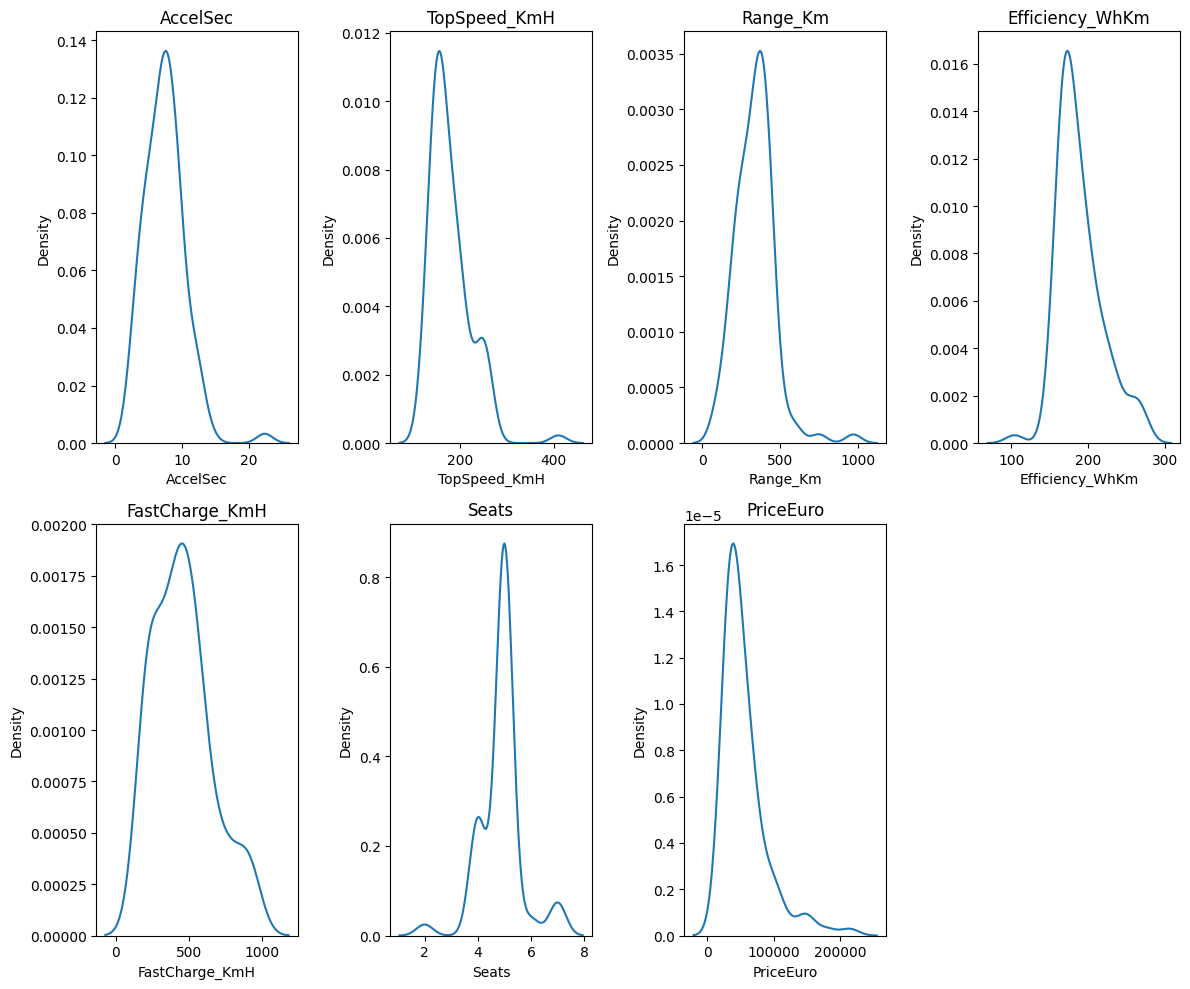

In [247]:
plt.figure(figsize=(12,10))

for index,col in enumerate(num):

  plt.subplot(2,4,index+1)
  sns.kdeplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()


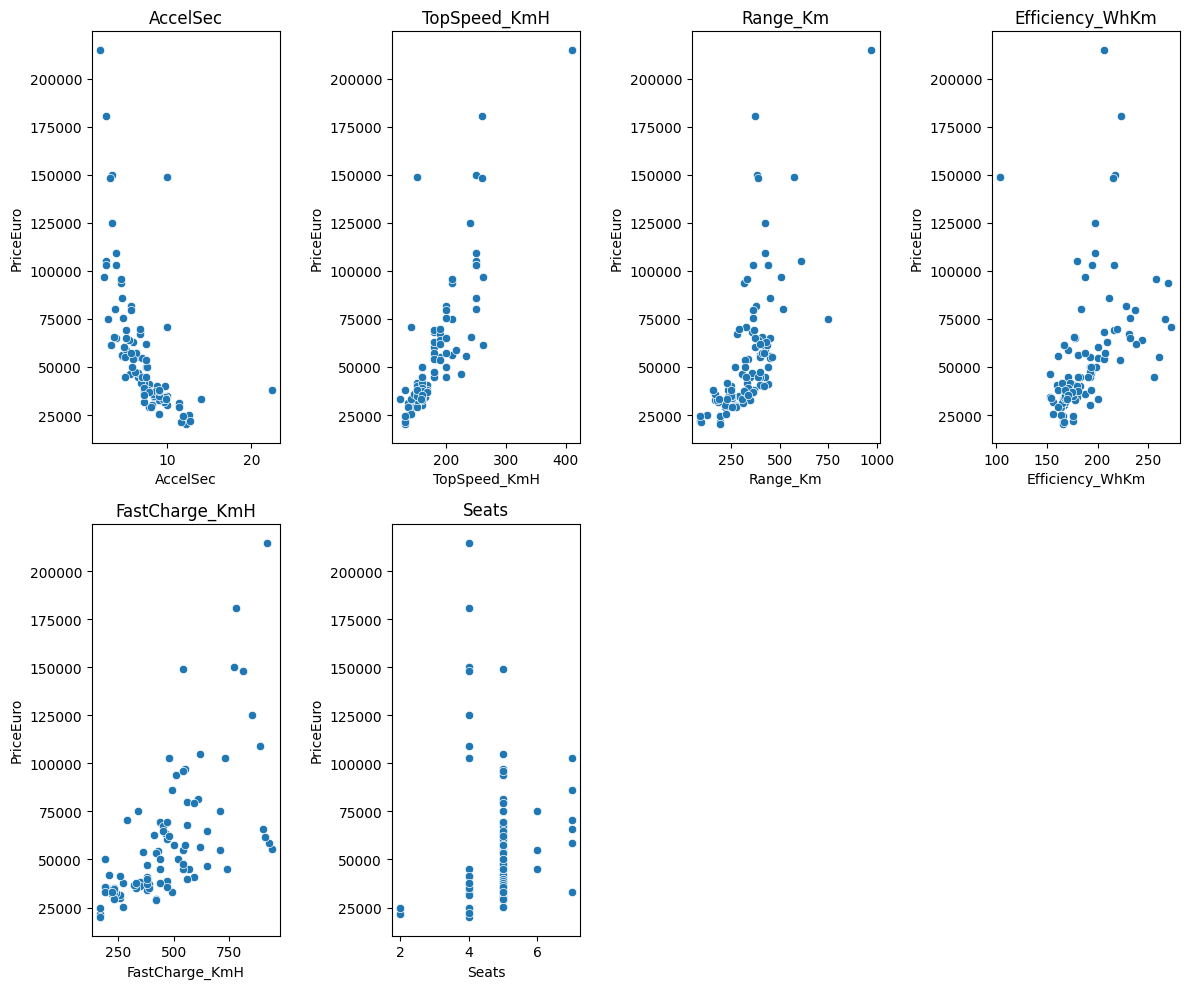

In [248]:
plt.figure(figsize=(12,10))


features_for_scatter = [col for col in num if col != 'PriceEuro']

for index,col in enumerate(features_for_scatter):

  plt.subplot(2,4,index+1)
  sns.scatterplot(x=data[col],y=data['PriceEuro'])
  plt.title(col)
  plt.tight_layout()
plt.show()

In [249]:
features_for_cat=[ 'RapidCharge', 'PowerTrain', 'PlugType', 'BodyStyle']

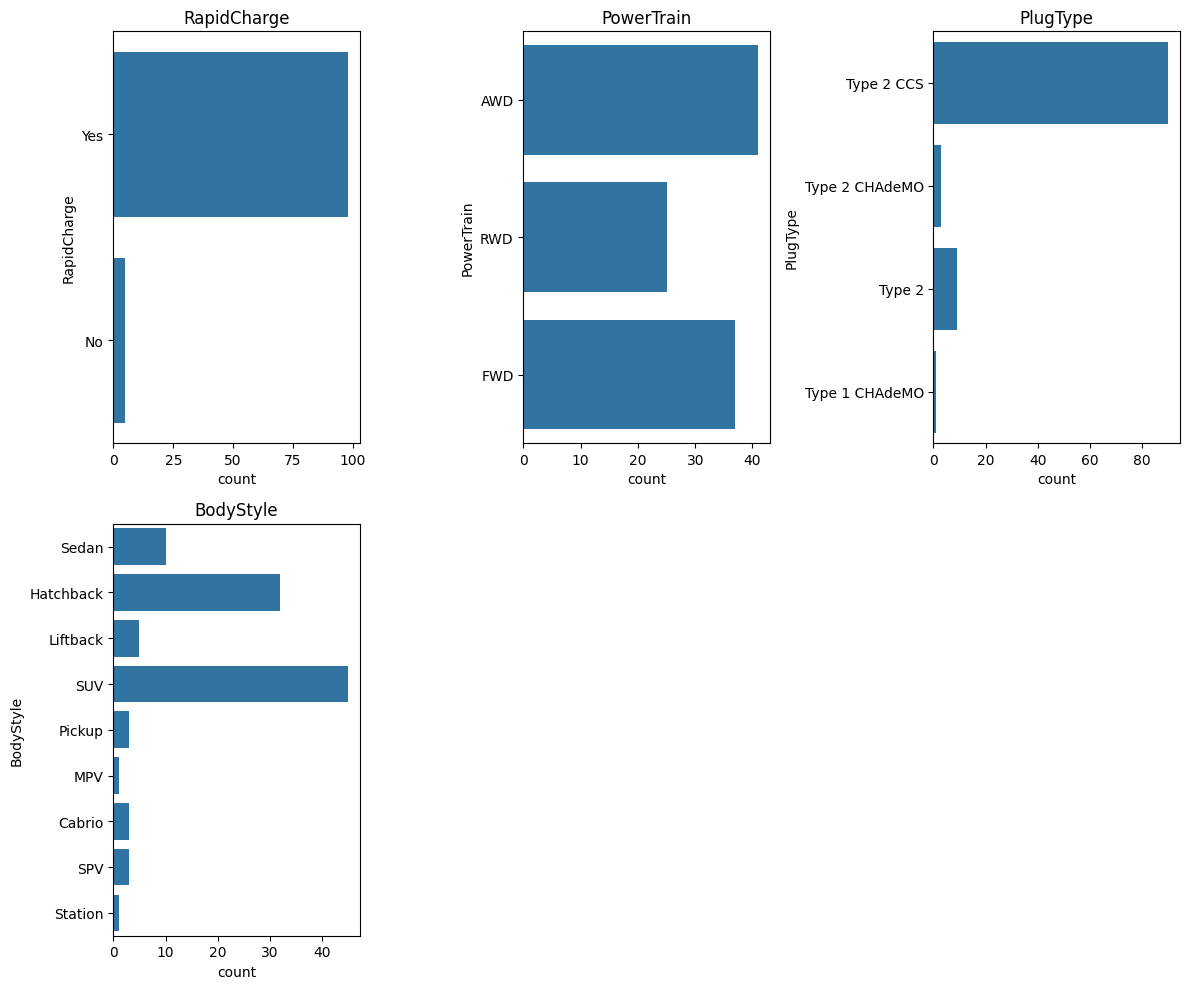

In [250]:
plt.figure(figsize=(12,10))




for index,col in enumerate(features_for_cat):

  plt.subplot(2,3,index+1)
  sns.countplot(data[col])
  plt.title(col)
  plt.tight_layout()
plt.show()

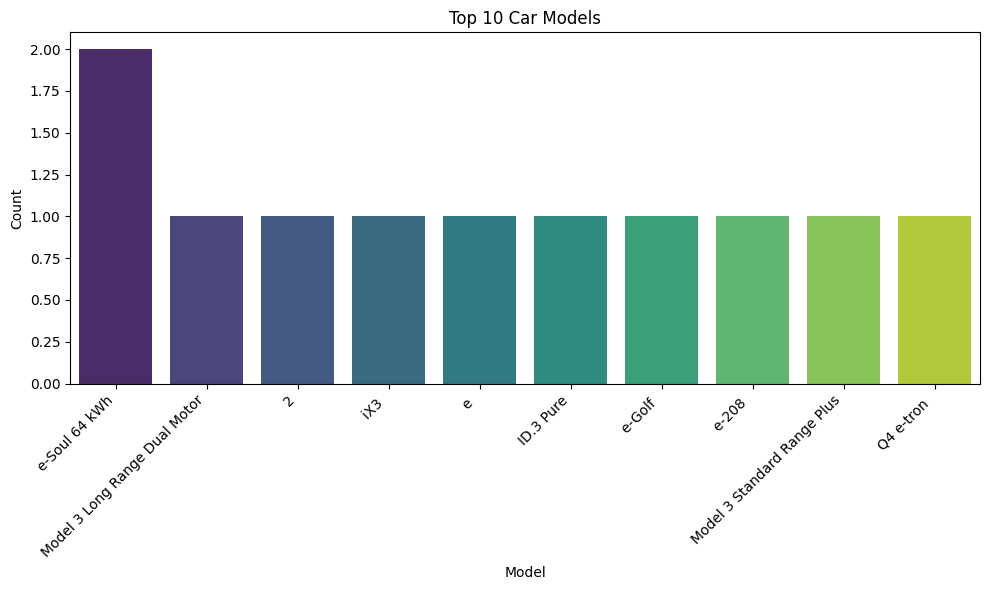

In [251]:
top_10_models = data['Model'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_models.index, y=top_10_models.values, palette='viridis', hue=top_10_models.index, legend=False)
plt.title('Top 10 Car Models')
plt.xlabel('Model')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [252]:
cat=['Brand', 'RapidCharge', 'PowerTrain','PlugType', 'BodyStyle', 'Segment']

### Preparing Data for Machine Learning

In [253]:

X = data.drop(['Model', 'PriceEuro'], axis=1)
y = data['PriceEuro']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [254]:
print("X_train info before ColumnTransformer:")
X_train.info()


numerical_features = ['AccelSec', 'TopSpeed_KmH', 'Efficiency_WhKm', 'FastCharge_KmH', 'Seats', 'Range_Km']
categorical_features = ['Brand', 'RapidCharge', 'PowerTrain', 'PlugType', 'BodyStyle', 'Segment']

numerical_transformer = pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Impute missing numerical values
    ('scaler', scaler()) # Standardize numerical features
])

categorical_transformer = pipeline(steps=[
    ('onehot', ohe(handle_unknown='ignore')) # One-hot encode categorical features
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = columnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns as they are, or drop if not needed
)


X_train info before ColumnTransformer:
<class 'pandas.core.frame.DataFrame'>
Index: 82 entries, 53 to 102
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            82 non-null     object 
 1   AccelSec         82 non-null     float64
 2   TopSpeed_KmH     82 non-null     int64  
 3   Range_Km         82 non-null     int64  
 4   Efficiency_WhKm  82 non-null     int64  
 5   FastCharge_KmH   77 non-null     float64
 6   RapidCharge      82 non-null     object 
 7   PowerTrain       82 non-null     object 
 8   PlugType         82 non-null     object 
 9   BodyStyle        82 non-null     object 
 10  Segment          82 non-null     object 
 11  Seats            82 non-null     int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 8.3+ KB


### Making Predictions and Evaluating the Model

In [255]:
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.ensemble import RandomForestRegressor


In [256]:
models = {
    'XGBoost': XGBRegressor(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'Linear Regression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42)
}

results = {}

for name, regressor in models.items():
    model_pipeline_new = pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', regressor)
    ])

    model_pipeline_new.fit(X_train, y_train)
    y_pred_new = model_pipeline_new.predict(X_test)

    r2 = r2_score(y_test, y_pred_new)
    mse = mean_squared_error(y_test, y_pred_new)

    results[name] = {'R-squared': r2, 'MSE': mse}

for name, metrics in results.items():
    print(f"--- {name} ---")
    print(f"R-squared: {metrics['R-squared']:.2f}")
    print(f"Mean Squared Error: {metrics['MSE']:.2f}")

--- XGBoost ---
R-squared: 0.70
Mean Squared Error: 240419520.00
--- Decision Tree ---
R-squared: 0.71
Mean Squared Error: 230199361.29
--- Gradient Boosting ---
R-squared: 0.92
Mean Squared Error: 66785456.88
--- Support Vector Regressor ---
R-squared: -0.48
Mean Squared Error: 1174569222.77
--- Linear Regression ---
R-squared: 0.90
Mean Squared Error: 82626826.32
--- RandomForest ---
R-squared: 0.88
Mean Squared Error: 93418149.83


### Improving Model Performance: Hyperparameter Tuning



In [257]:
from sklearn.model_selection import GridSearchCV

In [258]:

# We are tuning parameters within the 'regressor' step of our pipeline.
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}


model_pipeline = pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42)) # Initialize with a RandomForestRegressor
])


grid_search = GridSearchCV(model_pipeline, param_grid, cv=3, scoring='r2', verbose=2, n_jobs=-1)


grid_search.fit(X_train, y_train)


# Print the best parameters and best R-squared score
print("\nBest parameters found:", grid_search.best_params_)
print("Best R-squared score found:", grid_search.best_score_)

# Get the best model from the grid search
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_tuned = best_rf_model.predict(X_test)

# Evaluate the best model
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mae(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)

print(f"\nEvaluated Best RandomForestRegressor on Test Set (after tuning):")
print(f"R-squared: {r2_tuned:.2f}")
print(f"Mean Absolute Error: {mae_tuned:.2f}")
print(f"Mean Squared Error: {mse_tuned:.2f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters found: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 100}
Best R-squared score found: 0.4401658120991401

Evaluated Best RandomForestRegressor on Test Set (after tuning):
R-squared: 0.88
Mean Absolute Error: 6698.44
Mean Squared Error: 93418149.83
